# Классификация только по FFT-признакам

Амплитудный спектр в полосе 0.3-40 Гц по всем каналам (снят с усреднённой по классу волны). Пайплайн и валидация идентичны блокнотам ERP/ERSP/ICA, поэтому числа сравнимы напрямую.

---
## 1. Импорты и конфиг

In [1]:
import os, re, time, math, gc, collections, warnings
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.filter import filter_data, resample
import scipy.io as sio
from scipy.signal import butter, sosfiltfilt, hilbert
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GroupKFold, cross_val_score

warnings.filterwarnings("ignore"); mne.set_log_level("ERROR")
plt.rcParams["figure.dpi"] = 110

DATA_DIR    = r"C:\Users\User\Desktop\Python\eeg_files"
FEATURE_DIR = r"C:\Users\User\Desktop\Python\processed_eeg_files\v24_features"
PREP_CACHE  = os.path.join(FEATURE_DIR, "ica_v2_prep")
os.makedirs(PREP_CACHE, exist_ok=True)

FMIN, FMAX       = 0.3, 40.0
EXCLUDE_PATTERNS = ["M1", "M2", "EOG", "WOG"]
ICA_DECIM_SFREQ  = 256
RANDOM_SEED      = 42
N_FOLDS          = 5
CLASSES = ['s1','s2','s3','s4','s5','s6','s7','s8','s9','s10']
TIME_WINDOWS = [
    (0.00,0.05),(0.05,0.10),(0.10,0.15),(0.15,0.20),(0.20,0.28),
    (0.28,0.40),(0.40,0.55),(0.55,0.70),(0.70,1.00),(1.00,1.50),(1.50,2.00),
]
FREQ_BANDS = {"delta":(0.3,4),"theta":(4,8),"alpha":(8,13),"beta":(13,30),"gamma":(30,40)}
K_BEST = 150

files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".set")])
print(f"Файлов: {len(files)} | K_best(in-fold)={K_BEST}")

Файлов: 46 | K_best(in-fold)=150


---
## 2. Этап A — предобработка

In [2]:
def _eeglab_read(set_path):
    mat = sio.loadmat(set_path, squeeze_me=True, struct_as_record=False)
    eeg = mat["EEG"]
    n_ch, n_t, n_tr = int(eeg.nbchan), int(eeg.pnts), int(eeg.trials)
    sfreq, tmin = float(eeg.srate), float(eeg.xmin)
    ch_names = [str(np.atleast_1d(c.labels)[0]) for c in np.atleast_1d(eeg.chanlocs)]
    labels = []
    for ep in np.atleast_1d(eeg.epoch):
        et = ep.eventtype
        if isinstance(et, (int, float, np.integer, np.floating)):
            name = str(et)
        elif isinstance(et, str):
            name = et
        else:
            name = "/".join(str(x) for x in np.atleast_1d(et))
        toks = [t for t in name.split("/") if t in CLASSES]
        labels.append(toks[0] if toks else name)
    labels = np.array(labels)
    data_ref = eeg.data
    if isinstance(data_ref, np.ndarray) and data_ref.dtype.kind in "fiu":
        arr = np.asarray(data_ref, dtype=np.float32)
        if arr.ndim == 2:
            arr = arr.reshape(n_ch, n_t, n_tr, order="F")
        def gen():
            for tr in range(n_tr):
                yield arr[:, :, tr].astype(np.float64)
    else:
        fdt = os.path.join(os.path.dirname(set_path), str(data_ref))
        if not os.path.exists(fdt):
            fdt = set_path[:-4] + ".fdt"
        mm = np.memmap(fdt, dtype=np.float32, mode="r", shape=(n_ch, n_t, n_tr), order="F")
        def gen():
            for tr in range(n_tr):
                yield np.asarray(mm[:, :, tr], dtype=np.float64)
    return gen(), n_tr, sfreq, tmin, ch_names, labels

def preprocess_file(path):
    cache = os.path.join(PREP_CACHE, os.path.basename(path).replace(".set", "_prep.npz"))
    if os.path.exists(cache):
        d = np.load(cache, allow_pickle=True)
        return d["data"].astype(np.float32), d["lab"], d["times"], list(d["ch"])
    epi, n_tr, sfreq, tmin, ch_names, labels = _eeglab_read(path)
    keep = [i for i, c in enumerate(ch_names)
            if not any(p.upper() in c.upper() for p in EXCLUDE_PATTERNS)]
    kept = [ch_names[i] for i in keep]
    rs = []
    for ep_raw in epi:
        x = ep_raw[keep]
        if abs(sfreq - ICA_DECIM_SFREQ) > 1e-6:
            x = resample(x, up=float(ICA_DECIM_SFREQ), down=sfreq, axis=-1, verbose=False)
        rs.append(x.astype(np.float32))
    data = np.stack(rs, 0)
    sh = data.shape
    flt = filter_data(data.reshape(-1, sh[-1]).astype(np.float64),
                      float(ICA_DECIM_SFREQ), FMIN, FMAX, verbose=False)
    data = flt.reshape(sh).astype(np.float32)
    times = (tmin + np.arange(sh[-1]) / float(ICA_DECIM_SFREQ)).astype(np.float32)
    np.savez_compressed(cache, data=data.astype(np.float16),
                        lab=labels, times=times, ch=np.array(kept))
    return data, labels, times, kept

def reindex(data, ch_names, target):
    idx = [ch_names.index(c) for c in target]
    return data[:, idx, :]

print("Этап A: предобработка всех файлов + кэш\n")
t0 = time.time()
ch_sets = []
for i, fn in enumerate(files, 1):
    _, _, times_ref, ch = preprocess_file(os.path.join(DATA_DIR, fn))
    ch_sets.append(set(ch)); gc.collect()
    if i % 10 == 0 or i == len(files):
        print(f"  [{i}/{len(files)}] ({time.time()-t0:.0f}с)")
_, _, _, ch_first = preprocess_file(os.path.join(DATA_DIR, files[0]))
common_ch = [c for c in ch_first if all(c in s for s in ch_sets)]
print(f"\nОбщих каналов: {len(common_ch)} | точек во времени: {len(times_ref)}")

Этап A: предобработка всех файлов + кэш

  [10/46] (8с)
  [20/46] (16с)
  [30/46] (23с)
  [40/46] (30с)
  [46/46] (34с)

Общих каналов: 122 | точек во времени: 768


---
## 3. Извлечение признаков (FFT)

In [3]:
print("Извлечение FFT-признаков (амплитудный спектр по частотам, по всем каналам)...\n")
def fft_features(avg, t_f):
    n = avg.shape[-1]
    spec = np.abs(np.fft.rfft(avg, axis=-1)) / n          # амплитудный спектр (n_ch, n_freq)
    fr = np.fft.rfftfreq(n, d=1.0 / float(ICA_DECIM_SFREQ))
    mask = (fr >= FMIN) & (fr <= FMAX)                    # бины в полосе 0.3-40 Гц
    return spec[:, mask].ravel()

X, y, groups = [], [], []
t0 = time.time()
for i, fn in enumerate(files, 1):
    data, lab, t_f, ch = preprocess_file(os.path.join(DATA_DIR, fn))
    data = reindex(data, ch, common_ch)
    grp = re.match(r"(DIRe\d+_\d+)", fn).group(1)
    for cls in CLASSES:
        m = (lab == cls)
        if not m.any():
            continue
        X.append(fft_features(data[m].mean(0), t_f)); y.append(cls); groups.append(grp)
    del data; gc.collect()
    if i % 10 == 0 or i == len(files):
        print(f"  [{i}/{len(files)}] ({time.time()-t0:.0f}с)")
X = np.nan_to_num(np.array(X, np.float32))
y_str = np.array(y); day_groups = np.array(groups)
print(f"\nFFT-признаки: {X.shape} | примеров: {len(y_str)} | групп: {len(set(day_groups))}")

Извлечение FFT-признаков (амплитудный спектр по частотам, по всем каналам)...

  [10/46] (8с)
  [20/46] (16с)
  [30/46] (23с)
  [40/46] (30с)
  [46/46] (34с)

FFT-признаки: (460, 14640) | примеров: 460 | групп: 17


---
## 4. Классификация (6 моделей)

In [4]:
Xz = np.zeros_like(X, np.float32)                 # per-group z-score
for g in np.unique(day_groups):
    mm = day_groups == g
    Xz[mm] = StandardScaler().fit_transform(X[mm])
le = LabelEncoder().fit(y_str); yv = le.transform(y_str)   # int -> MLP с early_stopping ок
chance = 100 / len(le.classes_)
gkf = GroupKFold(n_splits=N_FOLDS)
kbest = min(K_BEST, Xz.shape[1])

def pipe(clf):
    return Pipeline([("sel", SelectKBest(f_classif, k=kbest)), ("clf", clf)])

models = {
    "Random Forest": RandomForestClassifier(n_estimators=1500, max_features="sqrt",
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_SEED),
    "SVM": SVC(kernel="linear", C=0.1, class_weight="balanced", random_state=RANDOM_SEED),
    "MLP": MLPClassifier(hidden_layer_sizes=(256,128), alpha=0.1, learning_rate_init=0.005,
        max_iter=500, early_stopping=True, random_state=RANDOM_SEED),
    "Logistic Regression": LogisticRegression(C=0.1, max_iter=2000, class_weight="balanced",
        solver="lbfgs", n_jobs=-1, random_state=RANDOM_SEED),
    "LDA": LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
}
models["Voting (RF+SVM+MLP)"] = VotingClassifier(estimators=[
    ("rf",  RandomForestClassifier(n_estimators=1500, max_features="sqrt",
            class_weight="balanced", n_jobs=-1, random_state=RANDOM_SEED)),
    ("svm", SVC(kernel="linear", C=0.1, class_weight="balanced",
            probability=True, random_state=RANDOM_SEED)),
    ("mlp", MLPClassifier(hidden_layer_sizes=(256,128), alpha=0.1, learning_rate_init=0.005,
            max_iter=500, early_stopping=True, random_state=RANDOM_SEED)),
], voting="soft", n_jobs=-1)

print(f"{'Модель':<25s} {'Accuracy':>16s}")
print("-" * 45)
res = {}
for name, mdl in models.items():
    cv = cross_val_score(pipe(mdl), Xz, yv, cv=gkf, groups=day_groups,
                         scoring="accuracy", n_jobs=-1)
    res[name] = (cv.mean(), cv.std())
    print(f"{name:<25s} {cv.mean()*100:>6.2f}% ± {cv.std()*100:>4.1f}%")
best = max(res, key=lambda n: res[n][0])
print(f"\nЛучшая (только FFT): {best} ({res[best][0]*100:.2f}%) | случайно {chance:.0f}%")

Модель                            Accuracy
---------------------------------------------
Random Forest              46.82% ±  3.7%
SVM                        46.60% ±  3.3%
MLP                        45.62% ±  4.2%
Logistic Regression        48.96% ±  4.2%
LDA                        55.96% ±  4.6%
Voting (RF+SVM+MLP)        47.67% ±  6.0%

Лучшая (только FFT): LDA (55.96%) | случайно 10%


---
## 5. График

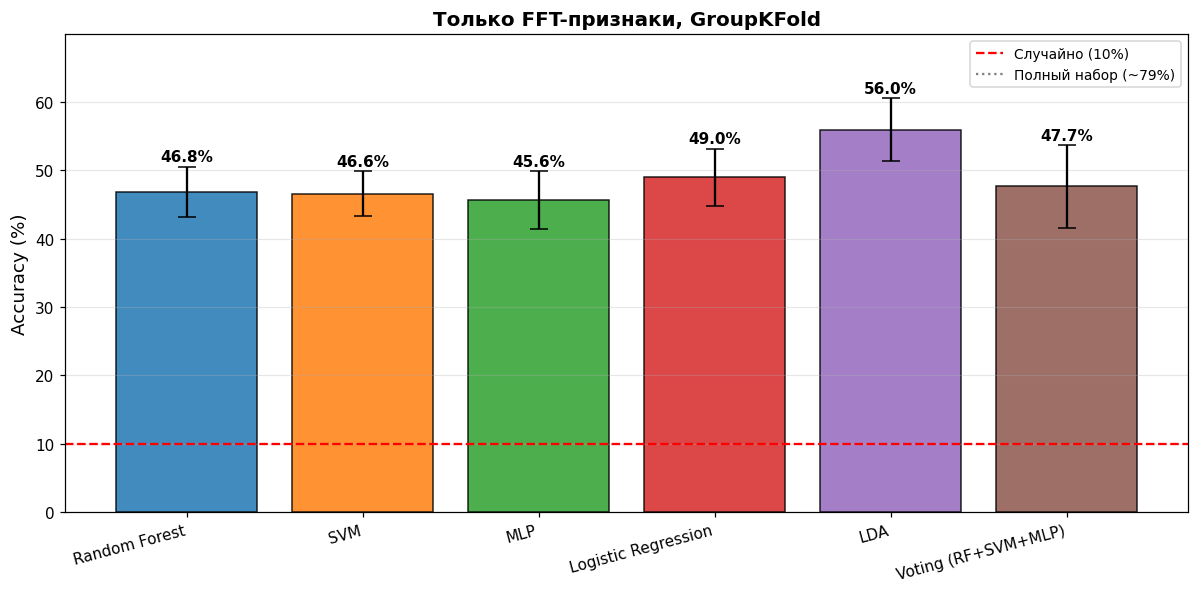

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))
names = list(res.keys())
vals  = [res[n][0] * 100 for n in names]
errs  = [res[n][1] * 100 for n in names]
ax.bar(names, vals, yerr=errs, capsize=6, color=plt.cm.tab10(np.arange(len(names))),
       alpha=0.85, edgecolor="black", linewidth=1)
ax.axhline(chance, ls="--", color="red", lw=1.5, label=f"Случайно ({chance:.0f}%)")
ax.axhline(79, ls=":", color="gray", lw=1.5, label="Полный набор (~79%)")
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Только FFT-признаки, GroupKFold", fontsize=13, fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(max(vals) * 1.25, 40))
plt.xticks(rotation=15, ha="right")
for i, (v, e) in enumerate(zip(vals, errs)):
    ax.text(i, v + e + 0.8, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()